In [1]:
from scipy.signal import firwin, freqz
import numpy as np
import matplotlib.pyplot as plt

In [7]:
Fs = 488281.25           # ADC sample rate (Hz)
fc = 110e3             # cutoff frequency (Hz)
numtaps = 201        # number of FIR taps (should be odd)
coef_bits = 16       # FIR Compiler coefficient width (bits)
beta = 9.0          # ~90 dB stopband attenuation
outfile = "fir_try_07022026_stage_3.coe"

In [8]:
h = firwin(
    numtaps = numtaps,
    cutoff = fc,
    fs=Fs,
    window=('kaiser', beta),
    pass_zero=True
)

In [9]:
scale = 2**(coef_bits - 1)
h_q = np.round(h * scale).astype(int)
# Clip (safety)
h_q = np.clip(h_q, -scale, scale-1)
for c in h:
    print(c, end=', ')

-5.094367293517976e-07, 4.018677181271171e-06, 2.746669559488671e-06, -6.263886298348154e-06, -7.246151675720671e-06, 7.4432757398779875e-06, 1.4320495032244622e-05, -5.955614929619102e-06, -2.360853887161871e-05, -8.658800087426787e-08, 3.3776508841189314e-05, 1.2474533765265451e-05, -4.2333693884806685e-05, -3.235697250318745e-05, 4.565862432660437e-05, 5.959631678326373e-05, -3.931752297955397e-05, -9.214037119915339e-05, 1.8719154168569822e-05, 0.00012556051429152073, 1.9909510802900664e-05, -0.0001529235753587215, -7.831767533019293e-05, 0.00016515042093947038, 0.00015496541700954361, -0.00015196377529227514, -0.00024393728798449105, 0.00010344140202146988, 0.0003343138472697225, -1.2076098467104556e-05, -0.0004102774116571739, -0.00012488398915943703, 0.0004521718023387203, 0.0003031613526111408, -0.0004386228249451025, -0.0005096759356222113, 0.0003496638449398328, 0.0007217391171790411, -0.00017061694450663545, -0.000907638150935862, -0.00010371791347980438, 0.00102890710293338

In [10]:
with open(outfile, "w") as f:
    f.write("; FIR Compiler coefficient file\n")
    f.write("radix = 10;\n")
    f.write("coefdata =\n")

    for i, coeff in enumerate(h):
        val = f"{coeff:.18f}".rstrip("0").rstrip(".")
        if i < len(h) - 1:
            f.write(val + ",\n")
        else:
            f.write(val + ";\n")

print(f"Correct FIR COE file written to {outfile}")

Correct FIR COE file written to fir_try_07022026_stage_3.coe


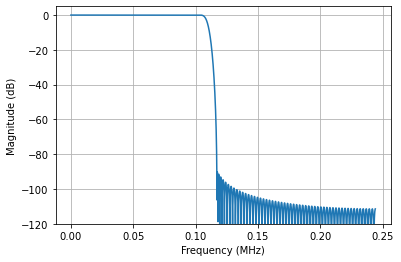

In [11]:
w, H = freqz(h, worN=4096)

f = w * Fs / (2 * np.pi)

plt.figure()
plt.plot(f / 1e6, 20 * np.log10(np.abs(H)))
plt.xlabel("Frequency (MHz)")
plt.ylabel("Magnitude (dB)")
plt.ylim([-120, 5])
plt.grid(True)
plt.show()